### Merge, Filter, Get Top Countries

In [5]:
import polars as pl
import os

In [35]:
train_df = pl.read_csv("../../datasets/google-landmark/raw-csv/train_set.csv")
index_df = pl.read_csv("../../datasets/google-landmark/raw-csv/index_set.csv")

In [ ]:
train_geocode = pl.read_csv(
    "../../datasets/google-landmark/raw-csv/train_set_reversed.csv"
).with_columns(pl.lit("train").alias("src"))
index_geocode = pl.read_csv(
    "../../datasets/google-landmark/raw-csv/index_set_reversed.csv"
).with_columns(pl.lit("index").alias("src"))

In [ ]:
pl.concat(
    [
        train_geocode.with_columns(pl.lit("train").alias("src")),
        index_geocode.with_columns(pl.lit("index").alias("src")),
    ]
).write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set.csv")

In [24]:
merged_set = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set.csv")
merged_set

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src
str,i64,f64,f64,str,str,str,str,str,str,str
"""6e158a47eb2ca3f6""",142820,59.341667,18.054722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SE""","""Sweden""","""Europe""","""Northern Europe""","""train"""
"""202cd79556f30760""",104169,56.123889,-3.947778,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
"""3ad87684c99c06e1""",37914,49.202,7.60012,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train"""
"""e7f70e9c61e66af3""",102140,3.521642,-76.417036,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CO""","""Colombia""","""South America""","""South America""","""train"""
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
…,…,…,…,…,…,…,…,…,…,…
"""ace1f52eea7620e9""",1463,53.001714,6.72987,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""f07d97acbc9cac79""",51420,52.377329,4.59569,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""2a2bdc07e5144f71""",27922,17.242778,98.972222,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""index"""


In [ ]:
with pl.Config(tbl_cols=-1, tbl_rows=-1):
    display(
        merged_set.group_by("country")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    )

country,count
str,u32
"""United States""",426551
"""Germany""",349319
"""United Kingdom""",287589
"""France""",214956
"""Italy""",147549
"""Spain""",140034
"""Czechia""",118643
"""Netherlands""",107002
"""Japan""",104844


In [ ]:
# Top-5 countries per region
region_country = (
    merged_set.filter(pl.col("country").is_not_null() & pl.col("region").is_not_null())
    .group_by(["region", "country"])
    .agg(pl.len().alias("count"))
)

top10_per_region = (
    region_country.with_columns(
        pl.col("count").rank("dense", descending=True).over("region").alias("rank")
    )
    .filter(pl.col("rank") <= 10)
    .filter(pl.col("count") >= 45000)
    .sort(["region", "rank"])
)

with pl.Config(tbl_rows=-1):
    display(top10_per_region)

region,country,count,rank
str,str,u32,u32
"""Asia""","""Japan""",104844,1
"""Asia""","""India""",68390,2
"""Asia""","""China""",47570,3
"""Europe""","""Germany""",349319,1
"""Europe""","""United Kingdom""",287589,2
"""Europe""","""France""",214956,3
"""Europe""","""Italy""",147549,4
"""Europe""","""Spain""",140034,5
"""Europe""","""Czechia""",118643,6


In [26]:
top_countries = top10_per_region["country"].to_list()
top_merged_set = merged_set.filter(pl.col("country").is_in(top_countries))

In [ ]:
top_merged_set.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries.csv"
)

In [ ]:
top_merged_set.sample(100).write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_sample.csv"
)

### Continuation of GeoTIR work (Paper #2)

#### OOD Benchmark

In [11]:
# os.listdir("/mnt/yokoyamalab-nas/gldv2-full/csv/v2")
merged_set = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set.csv")
merged_set

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src
str,i64,f64,f64,str,str,str,str,str,str,str
"""6e158a47eb2ca3f6""",142820,59.341667,18.054722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SE""","""Sweden""","""Europe""","""Northern Europe""","""train"""
"""202cd79556f30760""",104169,56.123889,-3.947778,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
"""3ad87684c99c06e1""",37914,49.202,7.60012,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train"""
"""e7f70e9c61e66af3""",102140,3.521642,-76.417036,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CO""","""Colombia""","""South America""","""South America""","""train"""
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
…,…,…,…,…,…,…,…,…,…,…
"""ace1f52eea7620e9""",1463,53.001714,6.72987,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""f07d97acbc9cac79""",51420,52.377329,4.59569,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""index"""
"""2a2bdc07e5144f71""",27922,17.242778,98.972222,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""index"""


In [12]:
merged_set.filter(pl.col("country").is_null())

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src
str,i64,f64,f64,str,str,str,str,str,str,str
"""8cb07825b419281e""",83610,42.666728,21.167131,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""train"""
"""0139633e31ec5ff9""",164121,42.7381,20.3058,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""train"""
"""e83edcce5f7c0c2c""",1127,43.269167,20.8225,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""train"""
"""196cef24451653d7""",162777,42.532778,20.140833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""train"""
"""28ac57d1a42947b7""",1127,43.269167,20.8225,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""train"""
…,…,…,…,…,…,…,…,…,…,…
"""d59b17f1fd36692f""",71283,null,null,null,null,null,null,null,null,"""index"""
"""31394d09937d0988""",66991,null,null,null,null,null,null,null,null,"""index"""
"""e735c564d586625f""",36603,42.661161,20.265619,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",null,null,null,null,"""index"""


In [15]:
merged_top_countries = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries.csv"
)
merged_top_countries.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src
str,i64,f64,f64,str,str,str,str,str,str,str
"""6e158a47eb2ca3f6""",142820,59.341667,18.054722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SE""","""Sweden""","""Europe""","""Northern Europe""","""train"""
"""202cd79556f30760""",104169,56.123889,-3.947778,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
"""3ad87684c99c06e1""",37914,49.202,7.60012,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train"""
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train"""
"""5554f8798114ed04""",149463,43.7226,-79.7208,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""CA""","""Canada""","""North America""","""Northern America""","""train"""


In [ ]:
top_countries = (
    merged_top_countries.select(pl.col("country_code"))
    .unique()
    .to_numpy()
    .squeeze()
    .tolist()
)

In [ ]:
merged_set.filter(~pl.col("country_code").is_in(top_countries)).write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/merged_set_non_top_countries.csv"
)

In [ ]:
asean_countries = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/merged_set_non_top_countries.csv"
)
asean_countries = asean_countries.filter(pl.col("subregion") == "South-eastern Asia")
asean_countries.write_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_countries.csv"
)

In [ ]:
asean_segment = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_countries_segment.csv"
)
asean_caption = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_countries_label_captions.csv"
)

In [87]:
asean_join = asean_caption.join(asean_segment, on="id")
asean_join.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption,ratio,threshold,is_landmark
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,f64,bool
"""1d3231ccc4b8581e""",187670,13.919832,100.622256,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""train""","""non_landmark""",0.9,"""A small red and white airplane…",0.010542,0.15,false
"""d14cb15e404a0674""",96991,14.32701,120.936077,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""A small church interior with w…",0.075296,0.15,false
"""d9b7e155c852d7eb""",184150,1.31543,103.858,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful Hindu temple entrance…",0.714067,0.15,true
"""d58efb61ad96c179""",165604,21.152547,94.858777,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""MM""","""Myanmar""","""Asia""","""South-eastern Asia""","""train""","""arch_gate""",0.9,"""Ancient stone structure with a…",0.316977,0.15,true
"""beac9aaa2c6343b2""",9075,13.414167,99.963333,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""train""","""non_landmark""",0.9,"""Ancient mural with golden Budd…",0.076412,0.15,false


In [ ]:
mapping = {
    "Timor-Leste": "Timor Leste",
    "Lao People's Democratic Republic": "Laos",
    "Viet Nam": "Vietnam",
}
col_mapping = {"pred_label": "category"}

asean_join = (
    asean_join.with_columns(pl.col("country").replace(mapping))
    .with_row_index("row_idx")
    .rename(col_mapping)
)

In [101]:
asean_filter = asean_join.filter(
    (pl.col("category") != "non_landmark") & (pl.col("is_landmark") == True)
)

In [ ]:
import sys

sys.path.append("..")
from src.data.query_builder import build_queries
import json

queries = build_queries(asean_filter)
with open("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_ood.json", "w") as f:
    f.write(json.dumps({"data": queries}))

In [ ]:
asean_filter = asean_filter.with_columns(
    (pl.col("country") + "|" + pl.col("category")).alias("stratify_key")
)

In [133]:
asean_filter.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean.csv")

In [135]:
asean_filter

row_idx,id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,category,pred_score,caption,ratio,threshold,is_landmark,stratify_key
u32,str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,f64,bool,str
2,"""d9b7e155c852d7eb""",184150,1.31543,103.858,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful Hindu temple entrance…",0.714067,0.15,true,"""Singapore|monument_statue"""
3,"""d58efb61ad96c179""",165604,21.152547,94.858777,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""MM""","""Myanmar""","""Asia""","""South-eastern Asia""","""train""","""arch_gate""",0.9,"""Ancient stone structure with a…",0.316977,0.15,true,"""Myanmar|arch_gate"""
5,"""3c33c7f81fe2c57b""",189231,15.2144,120.66,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""A stone statue in a garden wit…",0.584133,0.15,true,"""Philippines|monument_statue"""
7,"""e1f91a533e3a4ce0""",106602,1.28261,103.845,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful Hindu temple with sta…",0.90174,0.15,true,"""Singapore|monument_statue"""
9,"""2b8796a388a8087e""",106602,1.28261,103.845,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful statues on the roofto…",0.681729,0.15,true,"""Singapore|monument_statue"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73507,"""666c582a3503498e""",44895,-7.752,110.49122,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""ID""","""Indonesia""","""Asia""","""South-eastern Asia""","""index""","""monument_statue""",0.9,"""Ancient stone carvings depicti…",0.381372,0.15,true,"""Indonesia|monument_statue"""
73510,"""736612531fbd459a""",36627,14.0409,99.5036,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""TH""","""Thailand""","""Asia""","""South-eastern Asia""","""index""","""arch_gate""",0.9,"""Industrial arch gate with sign…",0.460425,0.15,true,"""Thailand|arch_gate"""
73512,"""1bbf7996a3db1fa1""",77405,15.3073,121.144,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""index""","""bridge""",0.9,"""A wooden bridge with stone pat…",0.379131,0.15,true,"""Philippines|bridge"""


In [111]:
asean_captions = asean_filter.group_by("stratify_key").agg("caption").to_dicts()
for c in asean_captions:
    c["caption"] = "\n".join(c["caption"])

In [116]:
result = await augment_queries(asean_filter)

augmenting captions: 100%|██████████| 52/52 [00:23<00:00,  2.25it/s]
/tmp/ipykernel_403010/1550844140.py:1: RuntimeWarning: coroutine 'augment_queries' was never awaited
  result = await augment_queries(asean_filter)


In [ ]:
query_df = pl.DataFrame(queries).with_columns(
    pl.concat_str(["country", "category"], separator="|").alias("stratify_key")
)
generated_df = pl.DataFrame(result).explode("augmented_captions")
query_df = query_df.join(generated_df, on="stratify_key")

KeyboardInterrupt: 

In [ ]:
new_queries = []
for res in result:
    country, category = res["stratify_key"].split("|")
    try:
        sample = list(
            filter(
                lambda x: (x["category"] == category) and (x["country"] == country),
                queries,
            )
        )[0]

        new_queries.append(sample)
        for r in res["augmented_captions"]:
            item = sample.copy()
            item["text"] = r
            new_queries.append(item)
    except Exception as e:
        print(country, category)
        print(e)

# print(len(uk_queries))
len(new_queries)

Timor Leste tower
list index out of range
Timor Leste palace_castle
list index out of range
Timor Leste bridge
list index out of range


294

In [ ]:
import json

with open(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_ood_augmented.json", "w"
) as f:
    f.write(json.dumps({"data": new_queries}))

OOD Benchmark (Test + OOD)

In [ ]:
test_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/test.csv").rename(
    {"pred_label": "category"}
)
asean_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/asean_ood.csv").drop(
    ["row_idx", "ratio", "threshold", "is_landmark"]
)

In [142]:
test_df.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,category,pred_score,caption,stratify_key
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
"""cfa552a8ad62142a""",158118,55.249983,-4.366351,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""arch_gate""",0.9,"""Ancient stone ruins with a cen…","""United Kingdom|arch_gate"""
"""b76fefa8adbdd62e""",63887,33.36425,132.513611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""JP""","""Japan""","""Asia""","""Eastern Asia""","""train""","""palace_castle""",0.9,"""Traditional Japanese building …","""Japan|palace_castle"""
"""3142152099d53719""",156682,8.077778,77.553889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""train""","""monument_statue""",0.9,"""A large statue of a figure hol…","""India|monument_statue"""
"""93594417929f7cd7""",21401,8.508611,76.955,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IN""","""India""","""Asia""","""Southern Asia""","""index""","""monument_statue""",0.9,"""Two stone pillars with bullet …","""India|monument_statue"""
"""f2dd46ae304a7f03""",140564,54.121389,-0.905833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""palace_castle""",0.9,"""Palace with classical architec…","""United Kingdom|palace_castle"""


In [143]:
asean_df.head()

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,category,pred_score,caption,stratify_key
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str,str
"""d9b7e155c852d7eb""",184150,1.31543,103.858,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful Hindu temple entrance…","""Singapore|monument_statue"""
"""d58efb61ad96c179""",165604,21.152547,94.858777,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""MM""","""Myanmar""","""Asia""","""South-eastern Asia""","""train""","""arch_gate""",0.9,"""Ancient stone structure with a…","""Myanmar|arch_gate"""
"""3c33c7f81fe2c57b""",189231,15.2144,120.66,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PH""","""Philippines""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""A stone statue in a garden wit…","""Philippines|monument_statue"""
"""e1f91a533e3a4ce0""",106602,1.28261,103.845,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful Hindu temple with sta…","""Singapore|monument_statue"""
"""2b8796a388a8087e""",106602,1.28261,103.845,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""SG""","""Singapore""","""Asia""","""South-eastern Asia""","""train""","""monument_statue""",0.9,"""Colorful statues on the roofto…","""Singapore|monument_statue"""


In [147]:
ood_df = pl.concat([test_df, asean_df])
ood_df.write_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/test_w_ood.csv")

#### Region and City Level Query

In [7]:
import polars as pl
import sys
import json

sys.path.append("..")
from src.data.query_builder import build_queries, augment_queries

In [3]:
test_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/test_w_city.csv")

In [4]:
template_queries = []
template_queries.extend(build_queries(test_df))
template_queries.extend(build_queries(test_df, granularity="region"))
template_queries.extend(build_queries(test_df, granularity="subregion"))
template_queries.extend(build_queries(test_df, granularity="city"))
len(template_queries)

[WARN] (arch_gate, Renigunta) has fewer than 5 relevant indices
[WARN] (palace_castle, Longqiao) has fewer than 5 relevant indices
[WARN] (bridge, Kurume) has fewer than 5 relevant indices
[WARN] (arch_gate, Trevignano Romano) has fewer than 5 relevant indices
[WARN] (tower, Saulieu) has fewer than 5 relevant indices
[WARN] (palace_castle, Rastatt) has fewer than 5 relevant indices
[WARN] (tower, Virserum) has fewer than 5 relevant indices
[WARN] (arch_gate, Sheridan) has fewer than 5 relevant indices
[WARN] (palace_castle, Bussiere-Galant) has fewer than 5 relevant indices
[WARN] (monument_statue, Pamplona) has fewer than 5 relevant indices
[WARN] (monument_statue, Nauvoo) has fewer than 5 relevant indices
[WARN] (bridge, Fuente el Fresno) has fewer than 5 relevant indices
[WARN] (tower, Dayton) has fewer than 5 relevant indices
[WARN] (monument_statue, Towson) has fewer than 5 relevant indices
[WARN] (tower, Narbonne) has fewer than 5 relevant indices
[WARN] (tower, Lochem) has fewer

8080

In [ ]:
with open(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2-ext/test_w_city_region.json", "w"
) as f:
    f.write(json.dumps({"data": template_queries}))

In [5]:
augmented_queries = []
augmented_queries.extend(await augment_queries(test_df))

augmenting captions (country):   0%|          | 0/75 [00:03<?, ?it/s]


BadRequestError: Error code: 400 - {'error': {'message': 'Your input exceeds the context window of this model. Please adjust your input and try again.', 'type': 'invalid_request_error', 'param': 'input', 'code': 'context_length_exceeded'}}

### DUMP, Check later

In [ ]:
preds = pl.read_csv("/tmp/sample_caption_output.csv")
preds.filter(pl.col("pred_label") != "non_landmark").select(
    ["id", "src", "pred_label", "pred_score", "caption"]
)

id,src,pred_label,pred_score,caption
str,str,str,f64,str
"""f7eb2a6c480fbf97""","""train""","""tower""",0.9,"""A white lighthouse on a sandy …"
"""c85a055b0986f1e1""","""train""","""palace_castle""",0.9,"""A historic stone house with a …"
"""2015fb23bdd66374""","""train""","""arch_gate""",0.9,"""A brick arch gate with the ins…"
"""1a7e39b37cfdab9f""","""train""","""tower""",0.9,"""A tall, white Art Deco buildin…"
"""ab505208130a4f5b""","""train""","""palace_castle""",0.9,"""A picturesque French castle wi…"
…,…,…,…,…
"""285463cbfe879d6d""","""train""","""palace_castle""",0.9,"""A grand red-brick castle with …"
"""634e2d324b9d5fd7""","""train""","""palace_castle""",0.9,"""Ruins of a historic building i…"
"""ed5872e830fdf9d1""","""train""","""bridge""",0.9,"""A bridge with a house in the b…"


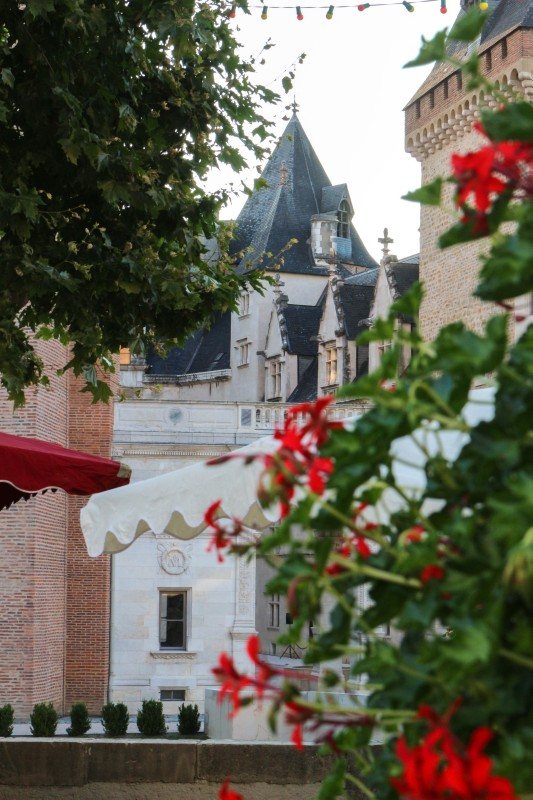

In [15]:
from PIL import Image

Image.open("/mnt/yokoyamalab-nas/gldv2-full/train/ab505208130a4f5b.jpg")

In [27]:
mp16_df = pl.read_csv("/mnt/yokoyamalab-nas/mp16/mp16_reversed.csv")
mp16_df

id,img_path,latitude,longitude,country_code,country,region,subregion
str,str,f64,f64,str,str,str,str
"""b5/e0/5825207952.jpg""","""./images/b5_e0_5825207952.jpg""",46.779843,22.129108,"""RO""","""Romania""","""Europe""","""Eastern Europe"""
"""43/8c/3350940420.jpg""","""./images/43_8c_3350940420.jpg""",37.761501,-122.424003,"""US""","""United States""","""North America""","""Northern America"""
"""ed/2c/8721739032.jpg""","""./images/ed_2c_8721739032.jpg""",45.135253,7.625481,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""b2/15/5334393895.jpg""","""./images/b2_15_5334393895.jpg""",37.790794,-122.43164,"""US""","""United States""","""North America""","""Northern America"""
"""9b/46/3578976721.jpg""","""./images/9b_46_3578976721.jpg""",28.369822,-81.554351,"""US""","""United States""","""North America""","""Northern America"""
…,…,…,…,…,…,…,…
"""2e/4d/462559192.jpg""","""./images/2e_4d_462559192.jpg""",-8.483578,115.563125,"""ID""","""Indonesia""","""Asia""","""South-eastern Asia"""
"""ac/28/3077185392.jpg""","""./images/ac_28_3077185392.jpg""",37.387489,-5.994468,"""ES""","""Spain""","""Europe""","""Southern Europe"""
"""d9/02/3646415834.jpg""","""./images/d9_02_3646415834.jpg""",-32.494564,137.765024,"""AU""","""Australia""","""Oceania""","""Australia and New Zealand"""


In [29]:
top_mp16_set = mp16_df.filter(pl.col("country").is_in(top_countries))
top_mp16_set

id,img_path,latitude,longitude,country_code,country,region,subregion
str,str,f64,f64,str,str,str,str
"""43/8c/3350940420.jpg""","""./images/43_8c_3350940420.jpg""",37.761501,-122.424003,"""US""","""United States""","""North America""","""Northern America"""
"""ed/2c/8721739032.jpg""","""./images/ed_2c_8721739032.jpg""",45.135253,7.625481,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""b2/15/5334393895.jpg""","""./images/b2_15_5334393895.jpg""",37.790794,-122.43164,"""US""","""United States""","""North America""","""Northern America"""
"""9b/46/3578976721.jpg""","""./images/9b_46_3578976721.jpg""",28.369822,-81.554351,"""US""","""United States""","""North America""","""Northern America"""
"""c0/28/6717205869.jpg""","""./images/c0_28_6717205869.jpg""",30.695718,-97.196044,"""US""","""United States""","""North America""","""Northern America"""
…,…,…,…,…,…,…,…
"""f8/62/4343249100.jpg""","""./images/f8_62_4343249100.jpg""",13.212665,77.439107,"""IN""","""India""","""Asia""","""Southern Asia"""
"""16/fd/5538692032.jpg""","""./images/16_fd_5538692032.jpg""",45.397636,10.899531,"""IT""","""Italy""","""Europe""","""Southern Europe"""
"""40/b3/4485932631.jpg""","""./images/40_b3_4485932631.jpg""",40.749439,14.003738,"""IT""","""Italy""","""Europe""","""Southern Europe"""


In [30]:
top_mp16_set.write_csv("/mnt/yokoyamalab-nas/mp16/csv/v1/mp16_set_top_countries.csv")

In [ ]:
top_mp16_set.with_columns(
    [pl.col("id").alias("id_ori"), pl.col("img_path").alias("id")]
).write_csv("/mnt/yokoyamalab-nas/mp16/csv/v1/mp16_set_top_countries.csv")

In [59]:
pl.read_csv("../../datasets/google-landmark/raw-csv/train_label_to_category.csv")

landmark_id,category
i64,str
0,"""http://commons.wikimedia.org/w…"
1,"""http://commons.wikimedia.org/w…"
2,"""http://commons.wikimedia.org/w…"
3,"""http://commons.wikimedia.org/w…"
4,"""http://commons.wikimedia.org/w…"
…,…
203089,"""http://commons.wikimedia.org/w…"
203090,"""http://commons.wikimedia.org/w…"
203091,"""http://commons.wikimedia.org/w…"


In [ ]:
gldv_train_latlon = pl.read_csv(
    "../../datasets/google-landmark/raw-csv/train_category_w_latlon.csv"
)
gldv_train_latlon

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,20,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '404 Not Found' f…"
null,39,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '404 Not Found' f…"
null,0,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",22.2728,114.182,null
null,2,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",47.959444,6.925556,null
null,4,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.895917,12.5005,null
…,…,…,…,…,…,…,…
null,203063,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",58.535961,31.276131,null
null,203069,"""http://commons.wikimedia.org/w…",null,null,null,null,"""No GeoHack coordinates found a…"
null,203074,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",50.181104,-5.070283,null


In [71]:
gldv_train = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/train_reversed.csv")
gldv_train

id,url,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error,country_code,country,region,subregion
str,str,i64,str,str,str,f64,f64,str,str,str,str,str
"""6e158a47eb2ca3f6""","""https://upload.wikimedia.org/w…",142820,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",59.341667,18.054722,null,"""SE""","""Sweden""","""Europe""","""Northern Europe"""
"""202cd79556f30760""","""http://upload.wikimedia.org/wi…",104169,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",56.123889,-3.947778,null,"""GB""","""United Kingdom""","""Europe""","""Northern Europe"""
"""3ad87684c99c06e1""","""http://upload.wikimedia.org/wi…",37914,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.202,7.60012,null,"""DE""","""Germany""","""Europe""","""Western Europe"""
"""e7f70e9c61e66af3""","""https://upload.wikimedia.org/w…",102140,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",3.521642,-76.417036,null,"""CO""","""Colombia""","""South America""","""South America"""
"""4072182eddd0100e""","""https://upload.wikimedia.org/w…",2474,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",51.685278,-2.543611,null,"""GB""","""United Kingdom""","""Europe""","""Northern Europe"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""fc0f007893b11ba7""","""https://upload.wikimedia.org/w…",172138,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",32.641861,34.924222,null,"""IL""","""Israel""","""Asia""","""Western Asia"""
"""39aad18585867916""","""https://upload.wikimedia.org/w…",162860,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…",null,null,null,null
"""fd0725460e4ebbec""","""https://upload.wikimedia.org/w…",191243,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",69.64807,18.9874,null,"""NO""","""Norway""","""Europe""","""Northern Europe"""


In [86]:
gldv_index = pl.read_csv("/home/affahrizain/Desktop/index_image_to_landmark.csv")
gldv_index

id,landmark_id
str,i64
"""fdf40612109ad174""",32888
"""5a6cc67c893daea6""",552
"""87b88acb68cdc1f1""",13626
"""c4ac217ce087b251""",8699
"""05f269bf32be9d3e""",30838
…,…
"""03947beda4345d37""",16254
"""5c11122e655fdf4e""",86165
"""9fff2d3c31495fa5""",48911


In [ ]:
gldv_index_latlon = pl.read_csv(
    "/home/affahrizain/Desktop/index_label_to_category_latlon.csv"
)
gldv_index_latlon

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,45,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.00767,12.379459,null
null,47,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",60.81051,21.447125,null
null,48,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",36.05686,120.33597,null
null,9,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",62.563056,28.790556,null
null,13,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",46.140577,14.396925,null
…,…,…,…,…,…,…,…
null,101198,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.381483,1.795853,null
null,101206,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.765707,20.453362,null
null,101218,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",29.962597,121.345725,null


In [112]:
gldv_index_latlon.filter(pl.col("error").str.contains("429"))

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,2076,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2280,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2286,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2291,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,2209,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
…,…,…,…,…,…,…,…
null,101109,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,101120,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"
null,101122,"""http://commons.wikimedia.org/w…",null,null,null,null,"""Client error '429 Too Many Req…"


In [ ]:
gldv_index_latlon.filter(
    ~pl.col("error").str.contains("429") | pl.col("error").is_null()
)  # .write_csv("/home/affahrizain/Desktop/index_label_to_category_latlon.csv")

id,landmark_id,input_url,resolved_url,geohack_url,latitude,longitude,error
str,i64,str,str,str,f64,f64,str
null,45,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",49.00767,12.379459,null
null,47,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",60.81051,21.447125,null
null,48,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",36.05686,120.33597,null
null,9,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",62.563056,28.790556,null
null,13,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",46.140577,14.396925,null
…,…,…,…,…,…,…,…
null,101198,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",41.381483,1.795853,null
null,101206,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",44.765707,20.453362,null
null,101218,"""http://commons.wikimedia.org/w…","""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…",29.962597,121.345725,null


In [ ]:
gldv_merged = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/merged_set_top_countries_caption_labels.csv"
)
gldv_merged
# gldv_merged.filter(pl.col("pred_label") != "non_landmark")
# with pl.Config(tbl_cols=-1, tbl_rows=-1):
# display(gldv_merged.filter(pl.col("pred_label") != "non_landmark").group_by("country").agg(pl.len().alias("total")).sort("total", descending=True))

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…"
"""16d8aa057cdd01b9""",25719,45.58359,9.27567,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""non_landmark""",0.9,"""Information board with text an…"
"""f1556e1eeeba213f""",36639,44.0446,-74.9325,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""non_landmark""",0.9,"""A small green plant growing on…"
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""non_landmark""",0.9,"""A serene stream flowing throug…"
"""3cdc355c6232712f""",12877,48.862444,2.395889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A memorial wall with numerous …"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""50792ccf8cf91575""",93260,22.2097,-159.477,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""non_landmark""",0.7,"""Historical street scene with b…"
"""1ded247f2ea76eea""",69456,38.890444,-77.069722,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""monument_statue""",0.9,"""A bronze statue of soldiers on…"
"""c13699e76340d47a""",22783,63.474167,-150.875833,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""index""","""non_landmark""",0.9,"""A small airplane flying over a…"


In [124]:
gldv_merged

id,landmark_id,latitude,longitude,wikimedia_url,geohack_url,country_code,country,region,subregion,src,pred_label,pred_score,caption
str,i64,f64,f64,str,str,str,str,str,str,str,str,f64,str
"""4b966789e0572456""",30319,52.226169,21.023186,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""PL""","""Poland""","""Europe""","""Eastern Europe""","""train""","""palace_castle""",0.9,"""Classical European building wi…"
"""16d8aa057cdd01b9""",25719,45.58359,9.27567,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""IT""","""Italy""","""Europe""","""Southern Europe""","""train""","""non_landmark""",0.9,"""Information board with text an…"
"""f1556e1eeeba213f""",36639,44.0446,-74.9325,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""US""","""United States""","""North America""","""Northern America""","""train""","""non_landmark""",0.9,"""A small green plant growing on…"
"""4072182eddd0100e""",2474,51.685278,-2.543611,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""GB""","""United Kingdom""","""Europe""","""Northern Europe""","""train""","""non_landmark""",0.9,"""A serene stream flowing throug…"
"""3cdc355c6232712f""",12877,48.862444,2.395889,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""FR""","""France""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A memorial wall with numerous …"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c239fe9d43ff0cd7""",107893,50.3317,7.90472,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train""","""tower""",0.9,"""A stone tower with a staircase…"
"""b2b4e9c0791788b8""",140192,52.202556,4.3925,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""NL""","""Netherlands""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.9,"""A historic church with a tall …"
"""eee4caa8c8b14928""",951,48.1136,11.6381,"""https://commons.wikimedia.org/…","""https://geohack.toolforge.org/…","""DE""","""Germany""","""Europe""","""Western Europe""","""train""","""non_landmark""",0.7,"""A serene lakeside with a red-r…"


In [118]:
train_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train.csv")
valid_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/valid.csv")
test_df = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/test.csv")

In [120]:
pl.concat([train_df, valid_df, test_df]).select(["id", "src"])

id,src
str,str
"""3f74003c5b060613""","""train"""
"""774a5eff9f01d1b3""","""train"""
"""91b70d0274d7e4a9""","""train"""
"""3111f4eeebd4e15e""","""train"""
"""1a10c0d307cf3e03""","""train"""
…,…
"""4f919fd72814dcc4""","""train"""
"""c6252911db901004""","""train"""
"""b0920dabb0b91a6b""","""train"""


In [ ]:
IMG_ROOT = "/mnt/yokoyamalab-nas/gldv2-full"
FILE_LIST_DIR = "/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp"

df = pl.concat([train_df, valid_df, test_df]).select(["id", "src"])

for src, group in df.group_by("src"):
    src = src[0]
    # relative paths → tar preserves train/ or index/ folder on extract
    paths = [f"{src}/{id_}.jpg" for id_ in group["id"].to_list()]
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    with open(list_path, "w") as f:
        f.write("\n".join(paths))
    print(f"Written {len(paths):,} paths → {list_path}")

print(f"\nRun these to bundle and split into 20GB chunks:")
for src in df["src"].unique().to_list():
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    out_prefix = f"{FILE_LIST_DIR}/gldv2_{src}.tar.part_"
    print(f"\n  # {src}")
    print(
        f"  tar -cf - -C {IMG_ROOT} --files-from={list_path} | split -b 20G - {out_prefix}"
    )

print(f"\nUpload with rclone:")
print(
    f"  rclone copy {FILE_LIST_DIR} onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress"
)

Written 456,629 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train_filelist.txt

Run these to bundle and split into 20GB chunks:

  # train
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/train_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/gldv2_train.tar.part_

Upload with rclone:
  rclone copy /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress


In [ ]:
tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=train_filelist.txt | pv | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v2/temp/gldv2_train.tar.part_

In [128]:
v1_train = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_train.csv")
v1_index = pl.read_csv("/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_index.csv")

In [ ]:
IMG_ROOT = "/mnt/yokoyamalab-nas/gldv2-full"
FILE_LIST_DIR = "/mnt/yokoyamalab-nas/gldv2-full/csv/v1"

df = pl.concat([v1_train, v1_index]).select(["id", "folder"])

for src, group in df.group_by("folder"):
    src = src[0]
    # relative paths → tar preserves train/ or index/ folder on extract
    paths = [f"{src}/{id_}.jpg" for id_ in group["id"].to_list()]
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    with open(list_path, "w") as f:
        f.write("\n".join(paths))
    print(f"Written {len(paths):,} paths → {list_path}")

print(f"\nRun these to bundle and split into 20GB chunks:")
for src in df["folder"].unique().to_list():
    list_path = f"{FILE_LIST_DIR}/{src}_filelist.txt"
    out_prefix = f"{FILE_LIST_DIR}/gldv2_{src}.tar.part_"
    print(f"\n  # {src}")
    print(
        f"  tar -cf - -C {IMG_ROOT} --files-from={list_path} | split -b 20G - {out_prefix}"
    )

print(f"\nUpload with rclone:")
print(
    f"  rclone copy {FILE_LIST_DIR} onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress"
)

Written 16,074 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v1/train_filelist.txt
Written 2,672 paths → /mnt/yokoyamalab-nas/gldv2-full/csv/v1/index_filelist.txt

Run these to bundle and split into 20GB chunks:

  # index
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v1/index_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v1/gldv2_index.tar.part_

  # train
  tar -cf - -C /mnt/yokoyamalab-nas/gldv2-full --files-from=/mnt/yokoyamalab-nas/gldv2-full/csv/v1/train_filelist.txt | split -b 20G - /mnt/yokoyamalab-nas/gldv2-full/csv/v1/gldv2_train.tar.part_

Upload with rclone:
  rclone copy /mnt/yokoyamalab-nas/gldv2-full/csv/v1 onedrive:gldv2/ --include '*.tar.part_*' --transfers 4 --progress


In [ ]:
captions = pl.read_csv(
    "/mnt/yokoyamalab-nas/gldv2-full/csv/v1/merged_set_train_labels.csv"
)["caption"].to_list()
captions[:5]

['A tall, red sandstone tower viewed through an archway in India, showcasing intricate brickwork and historical architecture.',
 'Two modern high-rise buildings under construction in Bahrain, with clear blue sky and parked cars in the foreground.',
 'A large, historic hotel with multiple towers and steep roofs, surrounded by dense green forest in the Canadian Rockies.',
 'White clock tower with a red dome, located in a city square with trees and parked cars, in Malaysia.',
 'A historic stone building with blue doors, surrounded by trees and a clear blue sky, located in Australia.']

In [ ]:
from transformers import AutoProcessor, AutoTokenizer
import sys

sys.path.append("..")
from src.geotir.train import CLIP_MODEL_NAME

tokenizer = AutoTokenizer.from_pretrained(CLIP_MODEL_NAME)

In [13]:
tokenized = tokenizer(
    captions,
    # truncation=True,
    # padding="max_length",
    # max_length=77,
    # return_tensors="pt"
)

In [14]:
lengths = []
for i in tokenized["input_ids"]:
    lengths.append(len(i))

In [15]:
max(lengths)

66